<a href="https://colab.research.google.com/github/edwardmoreno18/redesNeuronales2/blob/main/02_Frutas_Multicapa_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales II - Laboratorio B

## Red multicapa desde cero con NumPy

**Objetivo:** pasar de una sola neurona a una arquitectura **3 → 4 → 1**, usando ReLU en la capa oculta, Sigmoide en la salida y backpropagation manual.

In [6]:

# ============================================
# 1. LIBRERÍAS
# ============================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [7]:

# ============================================
# 2. DATASET DE FRUTAS: MANZANA VS BANANO
# ============================================
# Cada fila representa una fruta.
# Características:
#   - peso (gramos)
#   - longitud (cm)
#   - nivel de amarillo (0 a 1)
#
# Etiquetas:
#   0 = MANZANA
#   1 = BANANO

X = np.array([
    # MANZANAS
    [150, 7.5, 0.10], [160, 8.0, 0.15], [145, 7.2, 0.05],
    [170, 8.3, 0.20], [155, 7.8, 0.10], [165, 8.1, 0.15],
    [140, 7.0, 0.05], [175, 8.5, 0.20], [158, 7.9, 0.10],
    [162, 8.2, 0.15],

    # BANANOS
    [120, 18.0, 0.90], [125, 19.0, 0.95], [115, 17.5, 0.85],
    [130, 20.0, 1.00], [118, 18.5, 0.90], [123, 19.5, 0.95],
    [110, 17.0, 0.80], [128, 20.5, 1.00], [121, 18.8, 0.90],
    [126, 19.2, 0.95]
], dtype=float)

y = np.array([0] * 10 + [1] * 10).reshape(-1, 1)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (20, 3)
Forma de y: (20, 1)


In [8]:

# ============================================
# 3. SEPARAR ENTRENAMIENTO Y PRUEBA
# ============================================
# 80% de los datos se utilizan para aprender y 20% para comprobar
# si la red generaliza a ejemplos que no utilizó durante el entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16, 3)
X_test : (4, 3)
y_train: (16, 1)
y_test : (4, 1)


In [9]:
# ============================================
# 4. NORMALIZAR / ESTANDARIZAR
# ============================================
# Las tres características tienen escalas diferentes.
# StandardScaler transforma los datos para que trabajen en escalas comparables.

scaler = StandardScaler()

# IMPORTANTE:
# fit_transform SOLO se aplica al conjunto de entrenamiento.
# El conjunto de prueba se transforma con el mismo scaler.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos escalados correctamente.")
print("Primeras 5 filas escaladas:")
print(X_train[:5])


Datos escalados correctamente.
Primeras 5 filas escaladas:
[[ 1.10782916 -0.94158485 -0.93420715]
 [ 1.26848113 -0.95920515 -0.93420715]
 [-1.14129832  0.78520467  0.88863607]
 [-1.24839963  0.87330618  0.88863607]
 [-0.87354505  0.96140768  1.01015895]]


In [10]:

# ============================================
# 5. FUNCIÓN DE ACTIVACIÓN: SIGMOIDE
# ============================================
# La sigmoide transforma cualquier valor a un rango entre 0 y 1.
# En clasificación binaria la interpretamos como una probabilidad.

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ============================================
# 6. FUNCIÓN DE PÉRDIDA: BINARY CROSS ENTROPY
# ============================================
# Un loss pequeño significa que las predicciones están más cerca
# de las etiquetas reales.

def calcular_error(y_real, y_predicha):
    epsilon = 1e-8
    return -np.mean(
        y_real * np.log(y_predicha + epsilon)
        + (1 - y_real) * np.log(1 - y_predicha + epsilon)
    )


In [11]:

# ============================================
# LABORATORIO B - RED MULTICAPA DESDE CERO
# ============================================
# Arquitectura:
# 3 entradas -> 4 neuronas ocultas -> 1 salida
#
# La capa oculta utiliza ReLU.
# La salida utiliza Sigmoide porque seguimos resolviendo
# un problema binario.

def relu(z):
    return np.maximum(0, z)


def derivada_relu(z):
    return (z > 0).astype(float)


np.random.seed(42)

# He initialization para la capa oculta
W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))

# Inicialización de la capa de salida
W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

print("Forma de W1:", W1.shape)
print("Forma de W2:", W2.shape)


Forma de W1: (3, 4)
Forma de W2: (4, 1)


In [12]:
# ============================================
# FORWARD PROPAGATION MULTICAPA
# ============================================
Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

print("\nSalida de la capa oculta:", A1.shape)
print("Primeras probabilidades:")
print(A2[:5])


Salida de la capa oculta: (16, 4)
Primeras probabilidades:
[[0.42911408]
 [0.41367727]
 [0.35607532]
 [0.34175424]
 [0.27437375]]


In [13]:
# ============================================
# BACKPROPAGATION MULTICAPA
# ============================================
m = len(X_train)

# Gradiente de la capa de salida
dZ2 = A2 - y_train
dW2 = A1.T @ dZ2 / m
db2 = np.mean(dZ2, axis=0, keepdims=True)

# Propagar la señal de corrección hacia la capa oculta
dA1 = dZ2 @ W2.T
dZ1 = dA1 * derivada_relu(Z1)

dW1 = X_train.T @ dZ1 / m
db1 = np.mean(dZ1, axis=0, keepdims=True)


In [14]:
# ============================================
# ENTRENAMIENTO
# ============================================
np.random.seed(42)

W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

learning_rate = 0.05
epochs = 3000

loss_history_multicapa = []

for epoch in range(epochs):

    # 1. Forward
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # 2. Loss
    error = calcular_error(y_train, A2)
    loss_history_multicapa.append(error)

    # 3. Backpropagation
    m = len(X_train)

    dZ2 = A2 - y_train
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * derivada_relu(Z1)

    dW1 = X_train.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    # 4. Actualización
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 500 == 0:
        print(f"Época: {epoch:4d} | Error: {error:.4f}")


Época:    0 | Error: 0.9529
Época:  500 | Error: 0.0555
Época: 1000 | Error: 0.0259
Época: 1500 | Error: 0.0166
Época: 2000 | Error: 0.0122
Época: 2500 | Error: 0.0096


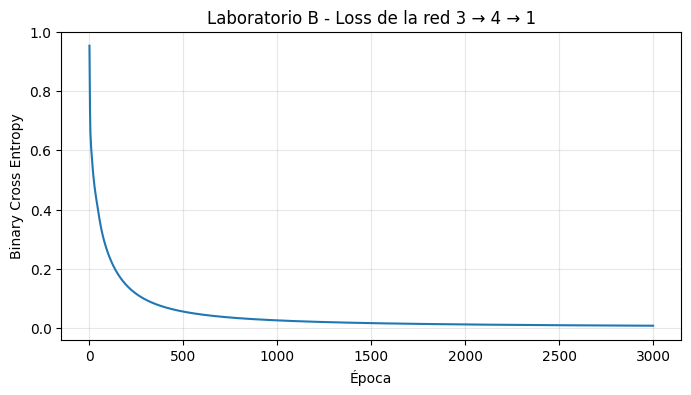

In [15]:
# ============================================
# GRÁFICA DEL LOSS
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(loss_history_multicapa)
plt.title("Laboratorio B - Loss de la red 3 → 4 → 1")
plt.xlabel("Época")
plt.ylabel("Binary Cross Entropy")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# ============================================
# EVALUACIÓN
# ============================================
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)

Z2_test = A1_test @ W2 + b2
probabilidades_test = sigmoid(Z2_test)

predicciones_multicapa = (probabilidades_test >= 0.5).astype(int)
accuracy_multicapa = np.mean(predicciones_multicapa == y_test)

print("Probabilidades:")
print(probabilidades_test)

print("\nPredicciones:")
print(predicciones_multicapa)

print("\nValores reales:")
print(y_test)

print(f"\nAccuracy en prueba: {accuracy_multicapa:.4f}")

Probabilidades:
[[1.42439384e-02]
 [2.06256532e-05]
 [9.85087119e-01]
 [9.85087119e-01]]

Predicciones:
[[0]
 [0]
 [1]
 [1]]

Valores reales:
[[0]
 [0]
 [1]
 [1]]

Accuracy en prueba: 1.0000


### Interpretación
Aquí la principal diferencia frente al laboratorio A es que la corrección debe propagarse desde la salida hacia la capa oculta. Por eso aparecen `dZ2`, `dW2`, `db2`, `dA1`, `dZ1`, `dW1` y `db1`.